In [1]:
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
from types import NoneType
import pandas as pd
import numpy as np
import os

from flow_analysis_tools.color_palettes import black_red_pastel_palette

In [2]:
SAMPLE_FILES = {
    "LX2": "/Users/alexandresathler/Library/CloudStorage/Box-Box/HsiungLab/Fibrosis/2026.02.23_DC_LX-2_TGFB RNA seq results/HM8D5T-expression-matrix.tsv",
    "pHSC": "/Users/alexandresathler/Library/CloudStorage/Box-Box/HsiungLab/Fibrosis/2026.05.23 pHSC_P7 TGFB RNA seq results/2HCQCH-expression-matrix.tsv",
}
SAMPLE_INDEXES = {
    "Ctrl": [0, 1],
    "TGF\u03b2": [2, 3]
}
OUTPUT_DIR = "/Users/alexandresathler/Library/CloudStorage/Box-Box/ARS_Working/Experiments/LX2-CRch-Const/1_CRch_Analysis/DNMT3A_Expression_Analysis"
GENES_OF_INTEREST = [
    "DNMT3A",
    "DNMT3AP1",
    "DNMT3L",
    "DNMT3B",
    "TILAM",
    "MEOX1",
    "CCN2", # aka Ctgf
    "POSTN",
    "JUNB",
    "GATA6",
    "TP73",
    "FOXC2",
    "YAP1",
    "WWTR1", # TAZ, another supposed mechanosensitive transcription factor
    "TGFBR1",
    "TGFBR2",
    "BRD2",
    "MYH9",
    "COL1A1",
    "SPI1", # see "PU.1 controls fibroblast..." (2019)
    "SMAD2",
    "SMAD3",
    "SMAD4",
    "NFX1",
    "C16orf87", # proposed renamed HDIP for HDAC-interacting protein
    "FOXO3",
    "CD47",
    "CD81",
    "CD151",
    "B2M",
]

In [3]:
TEST_GENE = GENES_OF_INTEREST[0]

In [4]:
class RNASeq_Data_File():
    def __init__(self, filepath, separ, name_col: str="gene_name"):
        self.filepath = filepath
        self.sep = separ
        self.gene_name_col = name_col
        assert os.path.isfile(self.filepath)
        self.df = pd.read_csv(self.filepath, sep=self.sep)
        self.gene_name_col_index = list(self.df.columns).index(self.gene_name_col)
        self.n_samples = int((self.df.shape[1] - 3) / 2) # assumed 3 header cols and both of: cpm, reads for each sample
        self.base_id = os.path.basename(self.filepath).split("-")[0]
        self.sample_names = [f"{self.base_id}_{x}_cpm" for x in range(1,self.n_samples+1)]
        self.sample_col_indexes = None
        self._index_sample_names()
        for sample_x in self.sample_names: assert sample_x in self.df.columns

    def _index_sample_names(self) -> NoneType:
        indexes = []
        for sample_name in self.sample_names:
            indexes.append(list(self.df.columns).index(sample_name))
        self.sample_col_indexes = indexes

    def get_sample_data(self, gene_names: list[str], sample_indexes: list[int]) -> list:
        df_gene_list = list(self.df[self.gene_name_col])
        gene_row_idx = []
        for gene in gene_names: gene_row_idx.append(df_gene_list.index(gene))
        sample_col_idx = [self.gene_name_col_index] + [self.sample_col_indexes[x] for x in sample_indexes]
        return_df = self.df.iloc[gene_row_idx, sample_col_idx]
        return_df.columns = ["gene_name"] + [f"rep_{str(x)}" for x in range(len(sample_indexes))]
        return return_df

    def head(self):
        return self.df.head()

    def info(self):
        print(f"{'Dataframe ID: ':<20}{self.base_id:>10}")
        print(f"{'Dataframe Rows: ':<20}{self.df.shape[0]:>10}")
        print(f"{'Dataframe Columns: ':<20}{self.df.shape[1]:>10}")
        print(f"{'Number of Samples: ':<20}{self.n_samples:>10}\n")
        print(f"{'Sample name: ':<20}{'Col Index':>10}")
        for idx in range(len(self.sample_names)):
            print(f"{self.sample_names[idx]:<20}{self.sample_col_indexes[idx]:>10}")

In [5]:
LX2_Data = RNASeq_Data_File(
    filepath=SAMPLE_FILES["LX2"],
    separ='\t'
)
LX2_Data.info()

Dataframe ID:           HM8D5T
Dataframe Rows:          78986
Dataframe Columns:          11
Number of Samples:           4

Sample name:         Col Index
HM8D5T_1_cpm                 3
HM8D5T_2_cpm                 5
HM8D5T_3_cpm                 7
HM8D5T_4_cpm                 9


In [6]:
LX2_Data.df.columns

Index(['gene_id', 'gene_name', 'gene_biotype', 'HM8D5T_1_cpm',
       'HM8D5T_1_count', 'HM8D5T_2_cpm', 'HM8D5T_2_count', 'HM8D5T_3_cpm',
       'HM8D5T_3_count', 'HM8D5T_4_cpm', 'HM8D5T_4_count'],
      dtype='object')

In [7]:
PHSC_Data = RNASeq_Data_File(
    filepath=SAMPLE_FILES["pHSC"],
    separ='\t'
)
PHSC_Data.info()

Dataframe ID:           2HCQCH
Dataframe Rows:          78986
Dataframe Columns:          11
Number of Samples:           4

Sample name:         Col Index
2HCQCH_1_cpm                 3
2HCQCH_2_cpm                 5
2HCQCH_3_cpm                 7
2HCQCH_4_cpm                 9


In [8]:
LX2_control_data = LX2_Data.get_sample_data(
    gene_names=GENES_OF_INTEREST,
    sample_indexes=SAMPLE_INDEXES["Ctrl"]
)
LX2_tgfb_data = LX2_Data.get_sample_data(
    gene_names=GENES_OF_INTEREST,
    sample_indexes=SAMPLE_INDEXES["TGFβ"]
)
# 2. Stack vertically (axis=0) and add source indicators
LX2_merged = pd.concat([LX2_control_data, LX2_tgfb_data], keys=['Ctrl', 'TGF\u03b2'])
LX2_merged = LX2_merged.reset_index(level=0).rename(columns={'level_0': 'sample'}).reset_index(drop=True)
LX2_merged['mean'] = np.mean(LX2_merged.loc[:,['rep_0', 'rep_1']], axis=1)

# LX2_merged['rep_0'] = LX2_merged['rep_0'] / LX2_merged['mean']
# LX2_merged['rep_1'] = LX2_merged['rep_1'] / LX2_merged['mean']
# LX2_merged[pd.isna(LX2_merged)] = 0
LX2_merged.head()

,sample,gene_name,rep_0,rep_1,mean
0,Ctrl,DNMT3A,13.592410,12.663244,13.127827
1,Ctrl,DNMT3AP1,0.000000,0.000000,0.000000
2,Ctrl,DNMT3L,0.000000,0.000000,0.000000
3,Ctrl,DNMT3B,9.617734,8.332524,8.975129
4,Ctrl,TILAM,1.275822,1.534939,1.405380


In [9]:
pHSC_control_data = PHSC_Data.get_sample_data(
    gene_names=GENES_OF_INTEREST,
    sample_indexes=SAMPLE_INDEXES["Ctrl"]
)
pHSC_tgfb_data = PHSC_Data.get_sample_data(
    gene_names=GENES_OF_INTEREST,
    sample_indexes=SAMPLE_INDEXES["TGFβ"]
)
# 2. Stack vertically (axis=0) and add source indicators
pHSC_merged = pd.concat([pHSC_control_data, pHSC_tgfb_data], keys=['Ctrl', 'TGF\u03b2'])
pHSC_merged = pHSC_merged.reset_index(level=0).rename(columns={'level_0': 'sample'}).reset_index(drop=True)
pHSC_merged['mean'] = np.mean(pHSC_merged.loc[:,['rep_0', 'rep_1']], axis=1)

# pHSC_merged['rep_0'] = pHSC_merged['rep_0'] / pHSC_merged['mean']
# pHSC_merged['rep_1'] = pHSC_merged['rep_1'] / pHSC_merged['mean']
# pHSC_merged[pd.isna(pHSC_merged)] = 0
pHSC_merged.head()

,sample,gene_name,rep_0,rep_1,mean
0,Ctrl,DNMT3A,15.433564,16.420069,15.926817
1,Ctrl,DNMT3AP1,0.000000,0.000000,0.000000
2,Ctrl,DNMT3L,0.000000,0.000000,0.000000
3,Ctrl,DNMT3B,3.180250,3.774729,3.477489
4,Ctrl,TILAM,7.108793,8.021298,7.565046


In [10]:
total_merged = pd.concat([LX2_merged,pHSC_merged], keys=["LX2", "pHSC"])
total_merged = total_merged.reset_index(level=0).rename(columns={'level_0': 'cell_type'}).reset_index(drop=True)
total_merged.head()

,cell_type,sample,gene_name,rep_0,rep_1,mean
0,LX2,Ctrl,DNMT3A,13.592410,12.663244,13.127827
1,LX2,Ctrl,DNMT3AP1,0.000000,0.000000,0.000000
2,LX2,Ctrl,DNMT3L,0.000000,0.000000,0.000000
3,LX2,Ctrl,DNMT3B,9.617734,8.332524,8.975129
4,LX2,Ctrl,TILAM,1.275822,1.534939,1.405380


In [11]:
total_merged = pd.melt(
    frame=total_merged, 
    id_vars=("cell_type", "sample", "gene_name", "mean"),
)

In [12]:
total_merged.head()

,cell_type,sample,gene_name,mean,variable,value
0,LX2,Ctrl,DNMT3A,13.127827,rep_0,13.592410
1,LX2,Ctrl,DNMT3AP1,0.000000,rep_0,0.000000
2,LX2,Ctrl,DNMT3L,0.000000,rep_0,0.000000
3,LX2,Ctrl,DNMT3B,8.975129,rep_0,9.617734
4,LX2,Ctrl,TILAM,1.405380,rep_0,1.275822


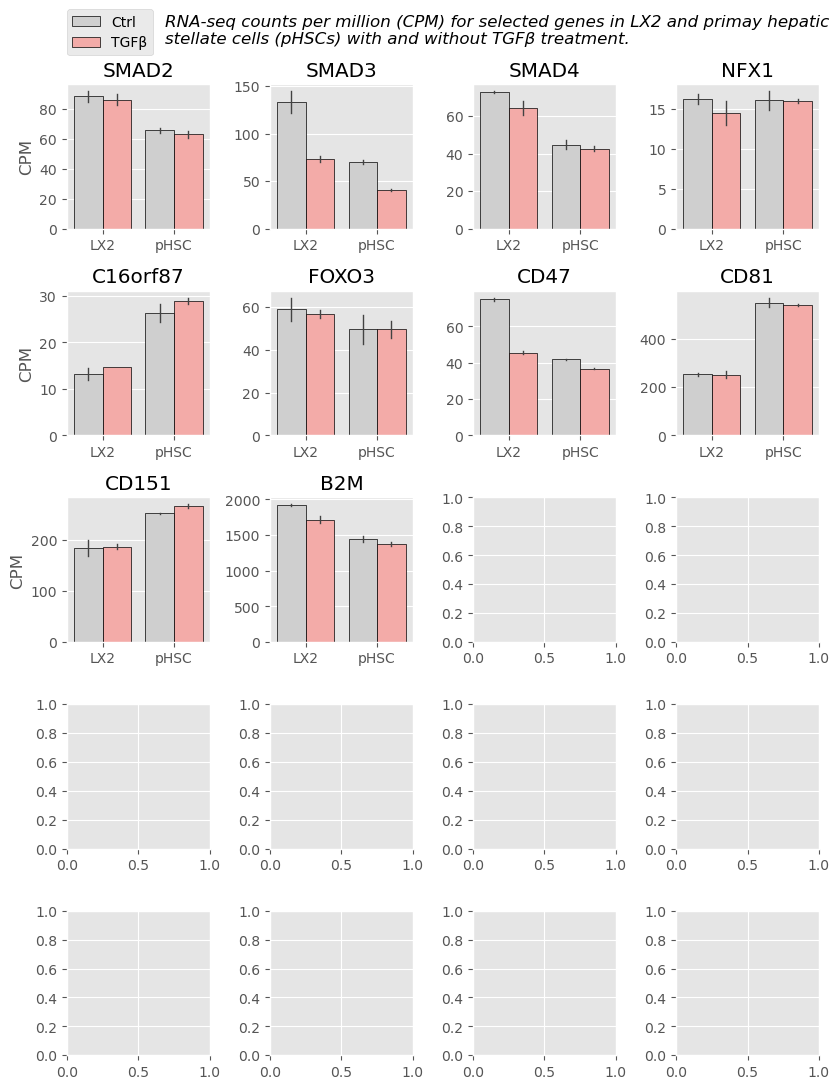

In [16]:
mpl.style.use("ggplot")
NROWS, NCOLS = 5, 4
fig, axes = plt.subplots(nrows = NROWS, ncols = NCOLS, figsize=(8.5,11), sharex=False, sharey=False)
# START, END = None, NROWS*NCOLS # to define how many genes are being graphed
START, END = NROWS * NCOLS, None
axes = axes.reshape((axes.shape[0] * axes.shape[1]))
for adx, gene in enumerate(GENES_OF_INTEREST[START:END]):
    these_data = total_merged.loc[total_merged['gene_name'] == gene]
    this_axis = axes[adx]
    sns.barplot(
        these_data, x="cell_type", y="value", 
        hue="sample", palette=black_red_pastel_palette, 
        edgecolor="black", linewidth=0.5,
        ax=this_axis, legend=True if adx==0 else False,
        errorbar="sd", capsize=0, err_kws={"linewidth": 1},
    )
    this_axis.set_title(gene)
    this_axis.set_xlabel(None)
    if np.all(these_data["mean"]) == 0: this_axis.set_ylim(0)
    if adx % NCOLS == 0: this_axis.set_ylabel("CPM")
    else: this_axis.set_ylabel(None)
    if adx == 0: this_axis.legend(loc=(0, 1.2))

this_legend = "RNA-seq counts per million (CPM) for selected genes in LX2 and primay hepatic\nstellate cells (pHSCs) with and without TGF\u03b2 treatment."
fig.text(x=0.2, y=0.955, s=this_legend, fontdict={"size": 12, "style": "italic"})
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, f"RNASeq_Gene_Exp_Analysis_{START}-{END}.pdf"))